In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI
from smt.sampling_methods import LHS


import os
import sys

# Changing directory to FEWNEW/work
# to import stuffs
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglikealt
import modeselectoralt
import parismc
# import gc
import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

# GPU configuration 
use_gpu = True
force_backend = "cuda12x"  
dt = 10     # Time step
T = 1/12     # Total time
print(f"Using dt = {dt} seconds, T = {T} years")

print('Initializing waveform generator...')
# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": force_backend # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": force_backend,  # Force GPU
    # "assume_positive_m": True  # if we assume positive m, it will generate negative m for all m>0
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs_comb = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
}

sum_kwargs_sep = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
    "separate_modes": True,
}

print("Creating GenerateEMRIWaveform class...")
# Kerr eccentric flux
waveform_gen_comb = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_comb,
    use_gpu=use_gpu
)

# Kerr eccentric flux
waveform_gen_sep = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_sep,
    use_gpu=use_gpu
)


print('Done initializing waveform generator.')

print("Creating GravWaveAnalysis class...")
gwf = GWfuncs.GravWaveAnalysis(T, dt)

print("Initializing loglike class...")


# Source parameters
m1 = 1e6
m2 = 3e1
a = 0.7
p0 = 15
e0 = 0.4 
# NOTE: BELOW FIXED
xI0 = 1.0
dist = 0.25 # Gpc
# Polar and azimuthal angles .. detector frame
# S = Solar system barycenter
# K = spin angular momentum of the MBH
qS = 0.5 
phiS = 1 
qK = 1 #fixed
phiK = phiS + np.pi/3
# Phases
Phi_phi0 = 0.4
Phi_theta0 = 0.0 # equatorial
Phi_r0 = 0.5

params_star = (m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

# Explicit mode groups: ℓ∈{2,3}, n∈{-5,-4,-3,-2,-1}
# Group modes by n value, including all m for each (ℓ,n) pair
# captures ~70% of SNR
mega_mode_groups = [
    # Group 1: All ℓ=3, n=-5 AND ℓ=2, n=-5
    [(3, 0, -5), (3, 1, -5), (3, 2, -5), (3, 3, -5), (3, -1, -5), (3, -2, -5), (3, -3, -5),
     (2, 0, -5), (2, 1, -5), (2, 2, -5), (2, -1, -5), (2, -2, -5)],

    # Group 2: All ℓ=3, n=-4 AND ℓ=2, n=-4
    [(3, 0, -4), (3, 1, -4), (3, 2, -4), (3, 3, -4), (3, -1, -4), (3, -2, -4), (3, -3, -4),
     (2, 0, -4), (2, 1, -4), (2, 2, -4), (2, -1, -4), (2, -2, -4)],

    # Group 3: All ℓ=3, n=-3 AND ℓ=2, n=-3
    [(3, 0, -3), (3, 1, -3), (3, 2, -3), (3, 3, -3), (3, -1, -3), (3, -2, -3), (3, -3, -3),
     (2, 0, -3), (2, 1, -3), (2, 2, -3), (2, -1, -3), (2, -2, -3)],

    # Group 4: All ℓ=3, n=-2 AND ℓ=2, n=-2
    [(3, 0, -2), (3, 1, -2), (3, 2, -2), (3, 3, -2), (3, -1, -2), (3, -2, -2), (3, -3, -2),
     (2, 0, -2), (2, 1, -2), (2, 2, -2), (2, -1, -2), (2, -2, -2)],

    # Group 5: All ℓ=3, n=-1 AND ℓ=2, n=-1
    [(3, 0, -1), (3, 1, -1), (3, 2, -1), (3, 3, -1), (3, -1, -1), (3, -2, -1), (3, -3, -1),
     (2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)],
]

# OLD n-indexed mode selection parameters (commented out)
# n_vals = np.arange(-5, 0)  # n from -5 to -1
# ell = 2  # quadrupole only

# NOTE: change verbose argument for debugging
# Using explicit mode groups via mode_select parameter
loglike_obj = loglikealt.LogLike(
    params_star,
    waveform_gen_comb,
    gwf,
    verbose=False,
    waveform_gen_sep=waveform_gen_sep,
    mode_select=mega_mode_groups,  # Use explicit mode groups
    M_mode=None  # No SNR filtering, use all mode groups
    # OLD: ell=ell, n_vals=n_vals
)

print('Done initializing loglike class.')
print('Calculating SNR...')
data = loglike_obj.signal
data_snr = gwf.rhostat(data)
print('SNR calculated:', data_snr)
print("Setting up log_density and prior functions...")


with open('cov_matrix_2yr.pkl', 'rb') as f:
    cov_matrix = pickle.load(f)

sigmas = np.sqrt(np.diag(cov_matrix))
print("2 year sigmas:", sigmas)
def log_density(params):
    params = np.asarray(params)

    n_samples = params.shape[0] 
    log_likes = np.zeros(n_samples)


    for i in range(n_samples):
        logm1, logm2, a, p0, e0 = params[i]
        m1 = 10**logm1
        m2 = 10**logm2

        loglike = loglike_obj(np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]))
        log_likes[i] = 10*loglike #NOTE: scaled 10x

    return log_likes

def prior_transform(u):
    n=1000
    logm1lim = [param_true[0] - n*sigmas[0], param_true[0] + n*sigmas[0]]
    logm2lim = [param_true[1] - n*sigmas[1], param_true[1] + n*sigmas[1]]
    alim = [param_true[2] - n*sigmas[2], min(param_true[2] + n*sigmas[2], 0.999)]  # a must be <1
    p0lim = [param_true[3] - n*sigmas[3], param_true[3] + n*sigmas[3]]
    e0lim = [param_true[4] - n*sigmas[4], param_true[4] + n*sigmas[4]]

    transformed = np.zeros_like(u)

    # Uniform in log for masses

    # m1
    transformed[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]

    # m2
    transformed[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]

    # Linear in others 

    # a
    transformed[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]

    # p0
    transformed[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0] 

    # e0
    transformed[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]

    
    return transformed

    

print('Done setting up log-likelihood and prior.')

Using dt = 10 seconds, T = 0.08333333333333333 years
Initializing waveform generator...
Creating GenerateEMRIWaveform class...
Done initializing waveform generator.
Creating GravWaveAnalysis class...
Initializing loglike class...
Done initializing loglike class.
Calculating SNR...
SNR calculated: 5.283339408229159
Setting up log_density and prior functions...
2 year sigmas: [8.47413325e-05 1.01378439e-04 3.49039352e-04 2.40285811e-03
 4.45624469e-05]
Done setting up log-likelihood and prior.


In [2]:
data_snr

array(5.28333941)

In [4]:
sampler = parismc.Sampler.load_state('./search/intrinsic_ffunc_1mth_evenmoremodes/sampler_state.pkl')

In [5]:
samples, weights = sampler.get_samples_with_weights(flatten=True)

In [6]:
n=1000
param_ranges = [(param_true[0] - n*sigmas[0], param_true[0] + n*sigmas[0]),
                (param_true[1] - n*sigmas[1], param_true[1] + n*sigmas[1]),
                (param_true[2] - n*sigmas[2], min(param_true[2] + n*sigmas[2], 0.999)),
                (param_true[3] - n*sigmas[3], param_true[3] + n*sigmas[3]),
                (param_true[4] - n*sigmas[4], param_true[4] + n*sigmas[4])
                ]
param_ranges

[(5.915258667542183, 6.084741332457817),
 (1.37574281578245, 1.5784996936568747),
 (0.350960648396513, 0.999),
 (12.597141890166823, 17.40285810983318),
 (0.3554375531246144, 0.44456244687538565)]

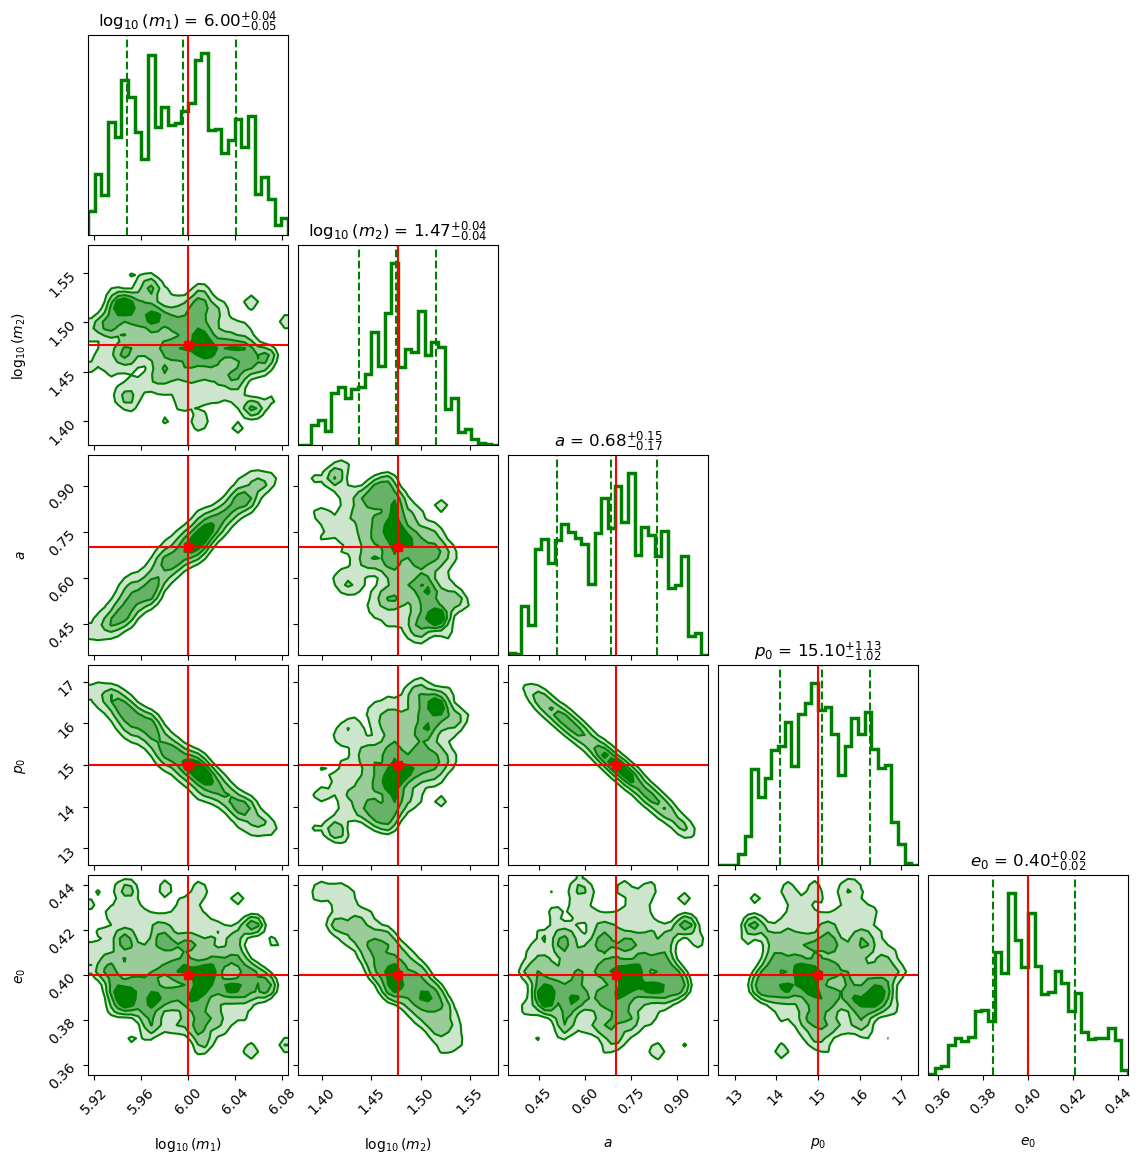

In [7]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

# corner.overplot_points(fig, proc1_maxld_pt.reshape(1, -1), 
#                        color='blue', marker='*', ms=10, 
#                        reverse=False)

# corner.overplot_points(fig, proc2_maxld_pt.reshape(1, -1), 
#                        color='orange', marker='*', ms=10,
#                        reverse=False)

